#  Exploratory Data Analysis - Tourism Wellness Package (Marketing)

## Importin  necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Import the data

In [5]:
df = pd.read_csv(r'travel_dataset.csv')
df

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,204883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4884,204884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0
4885,204885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,204886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0


## Check the shape of the data.

In [6]:
df.shape

(4888, 20)

**Observation:-** 
- There are `4888 rows` and `20 columns` in hte dataset.

## Checking the info of dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

**Observation:-**
- The dataset contains **4,888 customer records with 20 features**, and while most columns are complete, **several key numerical and categorical variables have missing values that need to be handled before analysis.**

---

## Checking for Duplicates.

In [8]:
df.duplicated().sum()

0

**Observation:-** 
- There are `no duplicates` in the dataset.

---

## Checking for missing values in the dataset.

In [9]:
df.isna().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

**Observation:-**
- Several important variables such as Age, DurationOfPitch, MonthlyIncome, NumberOfTrips, and NumberOfFollowups contain noticeable missing values, indicating the need for proper imputation before further analysis.

---

In [10]:
(df.isna().sum() * 100) / len(df)

CustomerID                  0.000000
ProdTaken                   0.000000
Age                         4.623568
TypeofContact               0.511457
CityTier                    0.000000
DurationOfPitch             5.135025
Occupation                  0.000000
Gender                      0.000000
NumberOfPersonVisiting      0.000000
NumberOfFollowups           0.920622
ProductPitched              0.000000
PreferredPropertyStar       0.531915
MaritalStatus               0.000000
NumberOfTrips               2.864157
Passport                    0.000000
PitchSatisfactionScore      0.000000
OwnCar                      0.000000
NumberOfChildrenVisiting    1.350245
Designation                 0.000000
MonthlyIncome               4.766776
dtype: float64

**Observation:-** 
- Since the missing values in all columns are less than 5%, they are minimal and can be safely removed by dropping the affected rows without risking loss of significant information or bias in the dataset.

---

## Drop the null values.

In [11]:
df.dropna(inplace = True)

**Observation:-** 
- all the duplicates have been Droped.

In [12]:
df.shape

(4128, 20)

**Observation:-** 
- Now there are `4128 rows` and `20 columns` in hte dataset.

## Converting the data types

In [13]:
object_cols = ['CityTier','ProdTaken','NumberOfPersonVisiting','OwnCar','NumberOfFollowups',
    'PreferredPropertyStar','NumberOfTrips','NumberOfChildrenVisiting','Passport','PitchSatisfactionScore']
df[object_cols] = df[object_cols].astype('object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4128 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4128 non-null   int64  
 1   ProdTaken                 4128 non-null   object 
 2   Age                       4128 non-null   float64
 3   TypeofContact             4128 non-null   object 
 4   CityTier                  4128 non-null   object 
 5   DurationOfPitch           4128 non-null   float64
 6   Occupation                4128 non-null   object 
 7   Gender                    4128 non-null   object 
 8   NumberOfPersonVisiting    4128 non-null   object 
 9   NumberOfFollowups         4128 non-null   object 
 10  ProductPitched            4128 non-null   object 
 11  PreferredPropertyStar     4128 non-null   object 
 12  MaritalStatus             4128 non-null   object 
 13  NumberOfTrips             4128 non-null   object 
 14  Passport     

## Cheaking the statistical description of data.

In [15]:
# Numerical Columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,4128.0,202527.763808,1409.439133,200000.0,201320.75,202603.5,203748.25,204887.0
Age,4128.0,37.231831,9.174521,18.0,31.00,36.0,43.00,61.0
DurationOfPitch,4128.0,15.584787,8.398142,5.0,9.00,14.0,20.00,127.0
MonthlyIncome,4128.0,23178.464147,4506.614622,1000.0,20751.00,22418.0,25301.00,98678.0


In [16]:
# Categorical Columns
df.describe(include = object)

,ProdTaken,TypeofContact,CityTier,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation
count,4128,4128,4128,4128,4128,4128,4128.0,4128,4128.0,4128,4128.0,4128,4128,4128,4128.0,4128
unique,2,2,3,4,3,5,6.0,5,3.0,4,12.0,2,5,2,4.0,5
top,0,Self Enquiry,1,Salaried,Male,3,4.0,Basic,3.0,Married,2.0,0,3,1,1.0,Executive
freq,3331,2918,2678,1999,2463,2078,1811.0,1615,2541.0,1990,1267.0,2909,1257,2527,1800.0,1615


In [17]:
cols = [
    'DurationOfPitch',
    'NumberOfFollowups',
    'PreferredPropertyStar',
    'NumberOfTrips',
    'NumberOfChildrenVisiting'
]

for col in cols:
    df[col] = df[col].astype(str).str.replace('.0', '', regex=False)


In [18]:
df['Gender'] = df['Gender'].replace("Fe Male", "Female")

In [19]:
# Store the clean CSV 
df = df.to_csv("Traveling_Data.csv", index=False)

---
# Visualization Part.
---

# Checking for outliers 

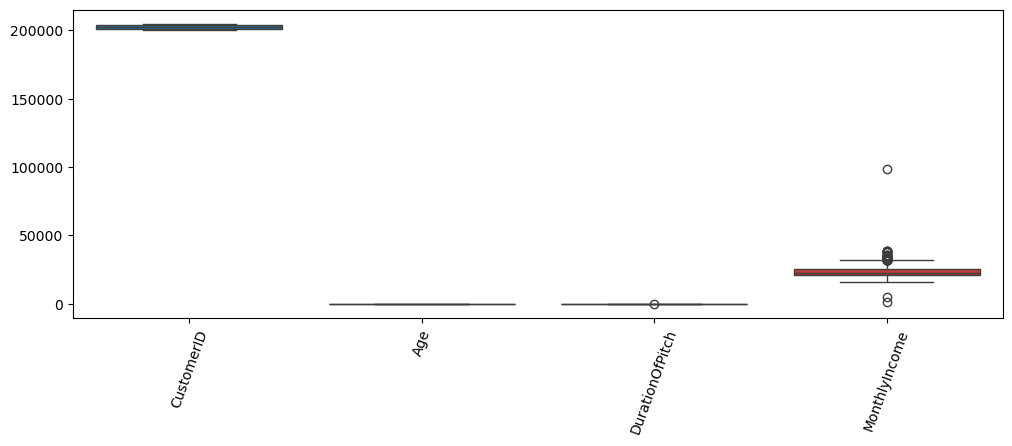

In [41]:
plt.figure(figsize=(12,4))
sns.boxplot(data=df.select_dtypes(include=['int64', 'float64']))
plt.xticks(rotation=70)
plt.show()

### 📌 Why these questions are important

By answering the above:

* We understand **who buys**, **why they buy**, and **what variables matter the most**
* We uncover **high-potential customer segments**
* We generate **actionable marketing and policy recommendations**


# Univariate Analysis
---
---

### 1️⃣ **What is the distribution of the target variable `ProdTaken`?**
**(How many customers purchased vs. did not purchase the package)**

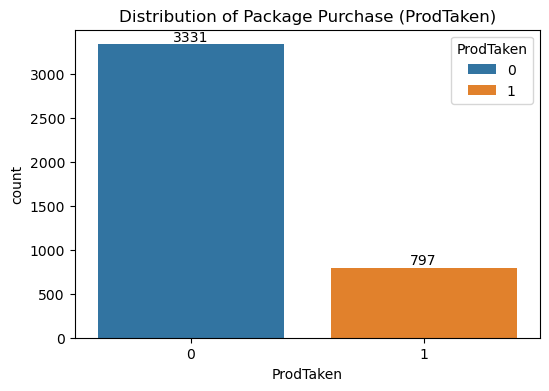

In [42]:
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='ProdTaken', hue = 'ProdTaken' )

for i in ax.containers:
    ax.bar_label(i)

plt.title("Distribution of Package Purchase (ProdTaken)")
plt.show()

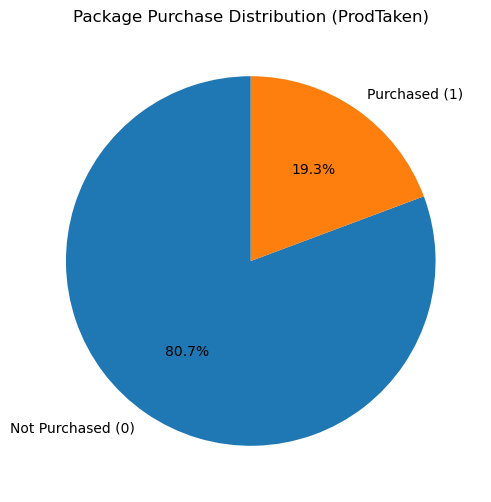

In [43]:
plt.figure(figsize=(6,6))
prod_counts = df['ProdTaken'].value_counts()
labels = ['Not Purchased (0)', 'Purchased (1)']
plt.pie(prod_counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Package Purchase Distribution (ProdTaken)")
plt.show()


---
**Observation:-**
> `80.7%` of customers did `not purchase` a travel package, while only `19.3%` `purchased` it.

**Business Insight:-**
> The imbalance between purchased and not purchased customers indicates that the existing marketing approach is broad and inefficient, resulting in high cost but low returns.

**Conclusion :-**
> Very low conversion (only 19.3%) highlights the need to identify potential customers before marketing, instead of contacting everyone randomly.

---
---

### 2️⃣ **What is the age distribution of customers?**
**(Young / middle-aged / senior — who forms the majority?)**

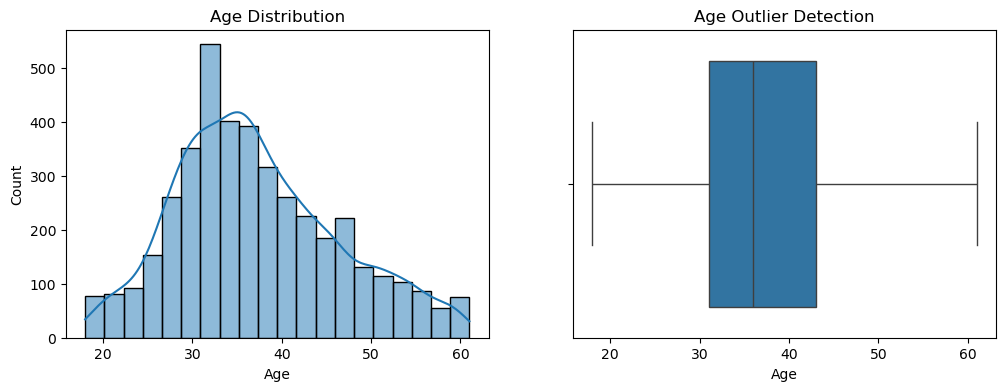

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.boxplot(x=df['Age'], ax=axes[1])
axes[1].set_title("Age Outlier Detection")

plt.show()


---
**Observation:-**

> The age of customers ranges approximately from **18 to 60 years**, with a **major concentration between 28 and 40 years**, showing a **slightly right-skewed distribution**.
> The boxplot indicates that the **median age lies around the mid-30s**, and **only a few mild outliers exist** on the younger and older ends.

**Business Insight:-**

> The customer base is largely **young working professionals and early middle-aged individuals**, which means the current audience already fits the target demographic for **wellness and lifestyle-oriented travel offerings**.

**Conclusion:-**

> **Most customers fall in the 28–40 age bracket, making it the primary potential segment for Wellness Tourism campaign strategies.**

---
---

### 3️⃣ **What is the distribution of customer income (`MonthlyIncome`)?**
**(Is the customer base low, middle, or high-income dominant?)**

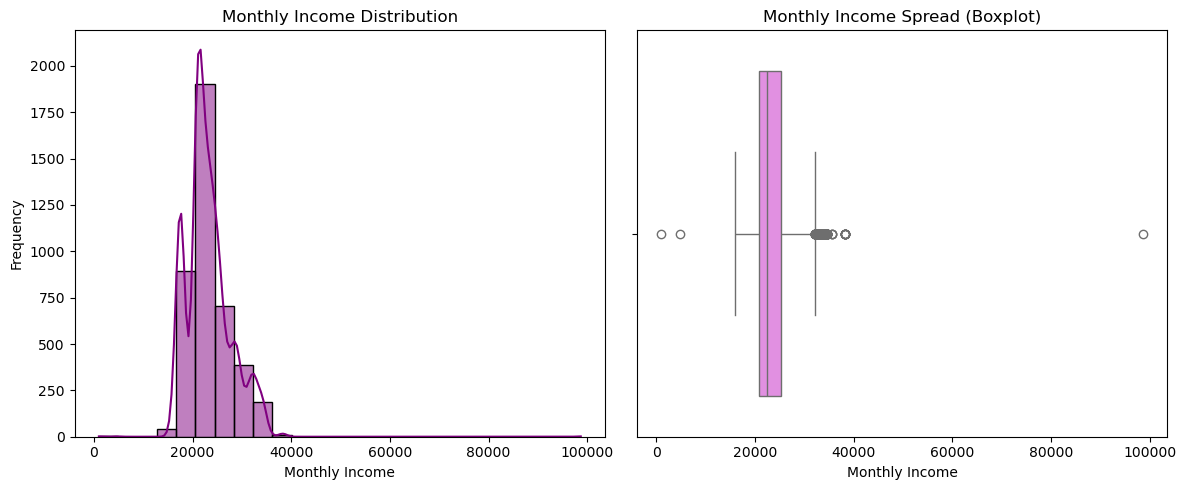

In [45]:
plt.figure(figsize=(12,5))

# Histogram + KDE
plt.subplot(1, 2, 1)
sns.histplot(df['MonthlyIncome'], kde=True, color='purple', bins=25)
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")

# Boxplot for outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=df['MonthlyIncome'], color='violet')
plt.title("Monthly Income Spread (Boxplot)")
plt.xlabel("Monthly Income")

plt.tight_layout()
plt.show()


---

**Observation :-**

> The income distribution is **right-skewed**, showing that most customers earn between **₹15,000 and ₹30,000 per month**, while a very small number of customers belong to the high-income segment (above ₹50,000–₹100,000).

**Business Insight:-**

> Since the majority of customers fall within the low-to-middle income range, **affordable packages with clear value benefits are more likely to convert compared to premium or luxury packages**.

**Conclusion :-**

> **The customer base is dominated by middle-income earners, so marketing should emphasize affordability, discounts, family benefits, EMI plans, and value-for-money messaging to drive conversions.**

---
---

### 4️⃣ **What is the distribution of travel behavior variables such as `NumberOfTrips`, `DurationOfPitch`, and `PitchSatisfactionScore`?**
**(Do most customers travel frequently? How long are pitches? Satisfaction levels?)**

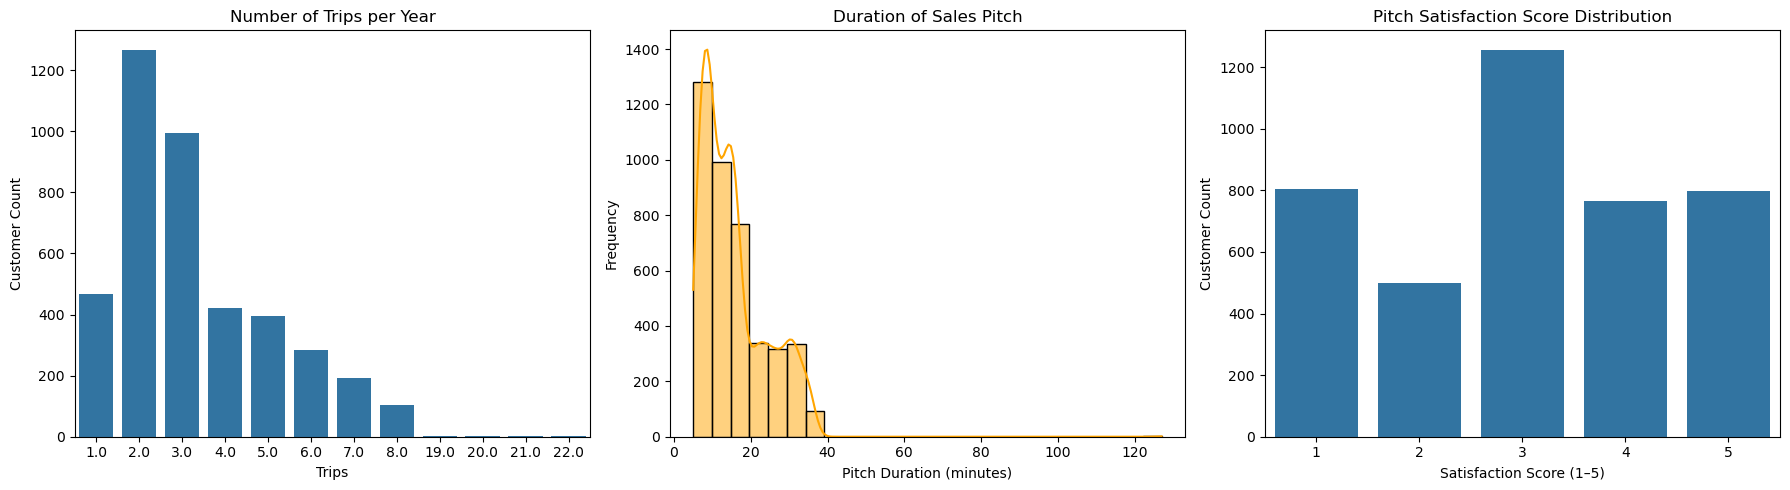

In [46]:
plt.figure(figsize=(18,5))

# Number of Trips
plt.subplot(1, 3, 1)
sns.countplot(x=df['NumberOfTrips'])
plt.title("Number of Trips per Year")
plt.xlabel("Trips")
plt.ylabel("Customer Count")

# Duration of Pitch
plt.subplot(1, 3, 2)
sns.histplot(df['DurationOfPitch'], kde=True, color='orange', bins=25)
plt.title("Duration of Sales Pitch")
plt.xlabel("Pitch Duration (minutes)")
plt.ylabel("Frequency")

# Pitch Satisfaction Score
plt.subplot(1, 3, 3)
sns.countplot(x=df['PitchSatisfactionScore'])
plt.title("Pitch Satisfaction Score Distribution")
plt.xlabel("Satisfaction Score (1–5)")
plt.ylabel("Customer Count")

plt.tight_layout()
plt.show()


---
**Observation :-**

> Most customers take **1–3 trips per year**; sales pitch duration is generally **between 10–25 minutes**, and the **most common satisfaction score is 3**, indicating a mid-level response to sales pitches.

**Business Insight :-**

> The customer base mostly consists of **occasional travelers**, and since **pitch satisfaction is average**, improving pitch quality could significantly increase conversions — especially within a **short, optimal pitch duration window (10–20 minutes)**.

**Conclusion :-**

> Customer travel behavior shows that **occasional travellers with moderate satisfaction toward sales pitches dominate the dataset; hence improving pitch quality and optimizing pitch duration to 10–20 minutes can potentially boost customer purchase rates.**

---
---

## 🔷 Bivariate Analysis (4 Questions)

### 5️⃣ **How does age vary with `ProdTaken`?**
**(Which age group is more likely to purchase?)**

C:\Users\nikhi\AppData\Local\Temp\ipykernel_22056\2214603187.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ProdTaken', y='Age', data=df, palette='Set2')


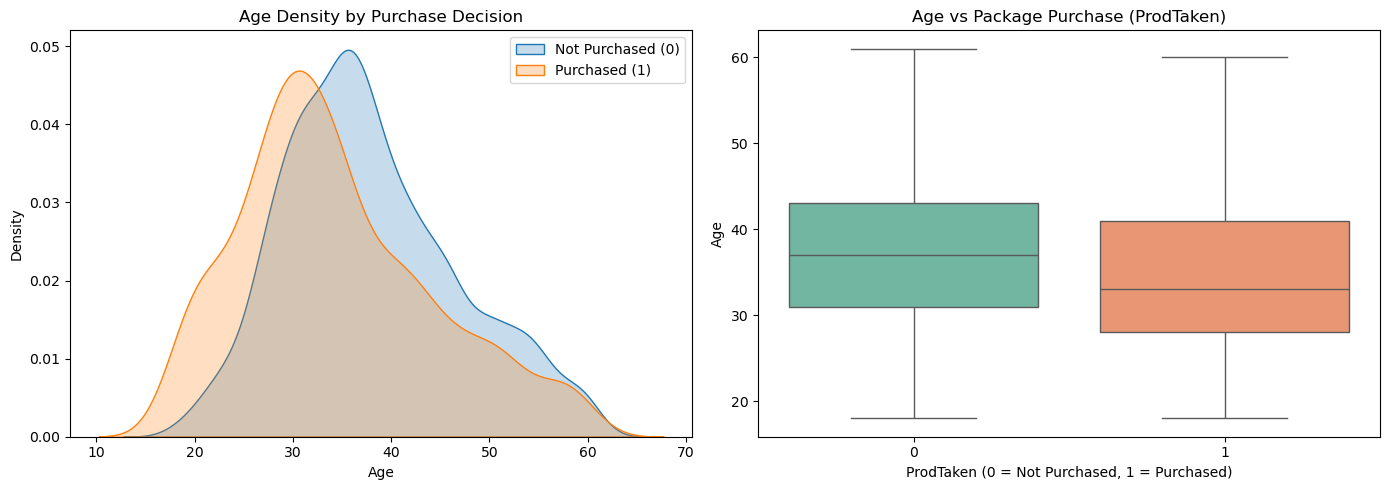

In [47]:
plt.figure(figsize=(14,5))

# KDE plot
plt.subplot(1, 2, 1)
sns.kdeplot(df[df['ProdTaken'] == 0]['Age'], label='Not Purchased (0)', fill=True)
sns.kdeplot(df[df['ProdTaken'] == 1]['Age'], label='Purchased (1)', fill=True)
plt.title("Age Density by Purchase Decision")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x='ProdTaken', y='Age', data=df, palette='Set2')
plt.title("Age vs Package Purchase (ProdTaken)")
plt.xlabel("ProdTaken (0 = Not Purchased, 1 = Purchased)")
plt.ylabel("Age")

plt.tight_layout()
plt.show()


---
**Observation :-**

> Customers who purchased the package are mostly in the **late 20s to mid-30s**, whereas those who did not purchase are comparatively **older on average (mid-30s to 40s)**.

**Business Insight :-**

> Younger customers tend to show **higher interest and willingness to purchase travel packages**, while older customers are less likely to convert even after engagement.

**Conclusion :-**

> **The ideal target age group for marketing the Wellness Tourism Package is the late-20s to mid-30s segment, as this group shows the highest purchase likelihood compared to older customers.**

---
---

### 6️⃣ **How does `MonthlyIncome` affect package purchasing?**
**(Do higher income customers buy more?)**

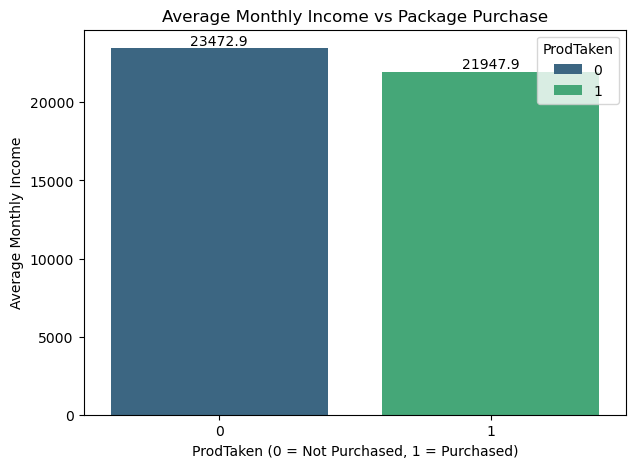

In [48]:
plt.figure(figsize=(7,5))
avg_income = df.groupby('ProdTaken')['MonthlyIncome'].mean().reset_index()

ax = sns.barplot(x='ProdTaken', y='MonthlyIncome', data=avg_income, hue = "ProdTaken", palette='viridis')

for i in ax.containers:
    ax.bar_label(i)

plt.title("Average Monthly Income vs Package Purchase")
plt.xlabel("ProdTaken (0 = Not Purchased, 1 = Purchased)")
plt.ylabel("Average Monthly Income")
plt.show()


---
**Observation :-**

> Customers who **did not purchase** the package have a **slightly higher average monthly income (~₹23,470)** compared to those who **purchased** (~₹21,950).

**Business Insight :-**

> Higher income customers are **less likely to purchase the current travel package**, indicating that the offering may not be appealing or premium enough for them.

**Conclusion :-**

> **Income does not positively drive package conversion; in fact, higher income customers purchase less, suggesting the need to segment marketing—premium offerings should target high-income customers while value packages should focus on middle-income groups.**

---
---

### 7️⃣ **Which occupation & designation groups show the highest purchase rate?**
**(Which customer segments are converting the most?)**

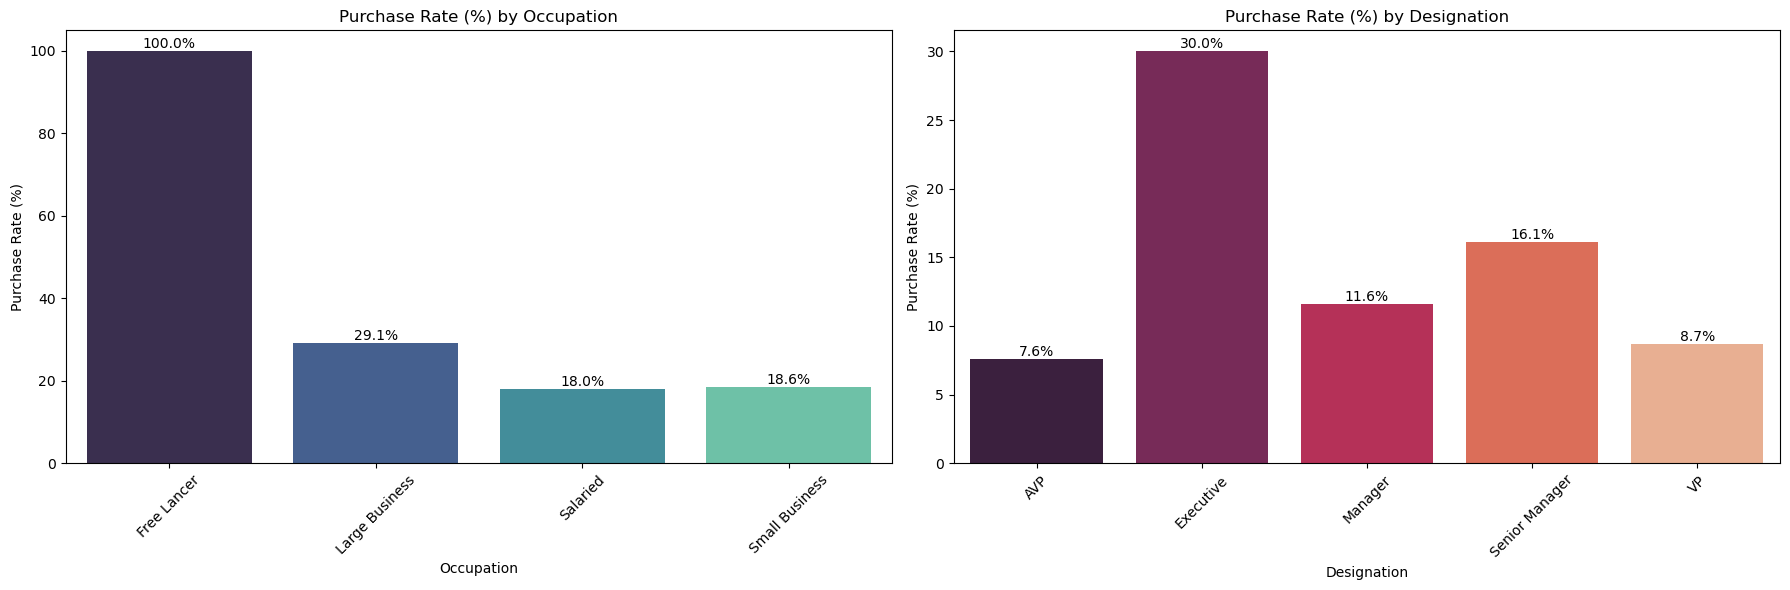

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# --- Occupation Purchase Rate ---
occupation_rate = df.groupby('Occupation')['ProdTaken'].mean().reset_index()
occupation_rate['ProdTaken'] = occupation_rate['ProdTaken'] * 100

ax1 = sns.barplot(x='Occupation', y='ProdTaken', data=occupation_rate, hue='Occupation', palette='mako', ax=axes[0])
for c in ax1.containers:
    ax1.bar_label(c, fmt='%.1f%%')

axes[0].set_title("Purchase Rate (%) by Occupation")
axes[0].set_ylabel("Purchase Rate (%)")
axes[0].set_xlabel("Occupation")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend([],[], frameon=False)


# --- Designation Purchase Rate ---
designation_rate = df.groupby('Designation')['ProdTaken'].mean().reset_index()
designation_rate['ProdTaken'] = designation_rate['ProdTaken'] * 100

ax2 = sns.barplot(x='Designation', y='ProdTaken', data=designation_rate, hue='Designation', palette='rocket', ax=axes[1])
for c in ax2.containers:
    ax2.bar_label(c, fmt='%.1f%%')

axes[1].set_title("Purchase Rate (%) by Designation")
axes[1].set_ylabel("Purchase Rate (%)")
axes[1].set_xlabel("Designation")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend([],[], frameon=False)

plt.tight_layout()
plt.show()


---
**Observation :-**

> Among occupations, **Freelancers show the highest purchase rate (100%)**, while **Salaried and Small Business customers show the lowest (~18%)**.
>
> Among designations, **Executives have the highest purchase rate (~30%)**, whereas **AVP and VP have the lowest (<10%)**.

**Business Insight :-**

> Individuals with **flexible work profiles (Freelancers) and lower designations (Executives)** are more likely to buy travel packages, while **senior-level and salaried professionals show lower conversion**, possibly due to limited time availability or lower interest in travel-based offers.

**Conclusion :-**

> **The strongest converting customer segments are Freelancers and Executives; therefore, marketing efforts should prioritize these profiles, while separate value-driven and premium-focused strategies should be crafted for salaried and senior-level professionals to improve conversion.**

---
---

### 8️⃣ **What is the impact of `NumberOfFollowups` and `DurationOfPitch` on purchase decision?**
**(Is there an optimal follow-up and pitch duration for conversion?)**

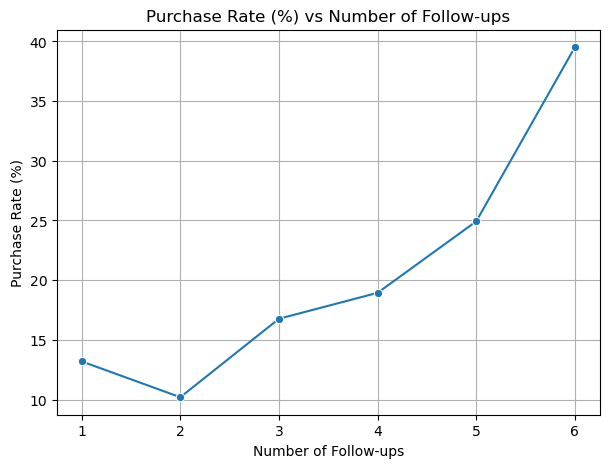

In [50]:
follow_rate = df.groupby('NumberOfFollowups')['ProdTaken'].mean() * 100

plt.figure(figsize=(7,5))
sns.lineplot(x=follow_rate.index, y=follow_rate.values, marker='o')
plt.title("Purchase Rate (%) vs Number of Follow-ups")
plt.xlabel("Number of Follow-ups")
plt.ylabel("Purchase Rate (%)")
plt.grid(True)
plt.show()


---
**Observation :-**

> Purchase probability increases consistently with more follow-ups, rising from around **13% at 1 follow-up** to **nearly 40% at 6 follow-ups**, indicating a strong positive correlation between follow-ups and conversion rate.

**Business Insight :-**

> Customers often require **multiple reminders before making a purchase decision**, and stopping follow-ups too early results in missed conversions — persistence directly improves sales effectiveness.

**Conclusion :-**

> **An optimal follow-up strategy is crucial — customers show the highest purchase rate after 5–6 follow-ups; therefore, the sales team should ensure consistent follow-up rather than closing the lead early for maximum conversions.**

---
---

# Multivariate Analysis 

### 9️⃣ **How do income + occupation + designation together influence the likelihood of purchasing the package?**
**(Can a business persona be created — such as “high-income corporate professionals are more likely to buy”?)**

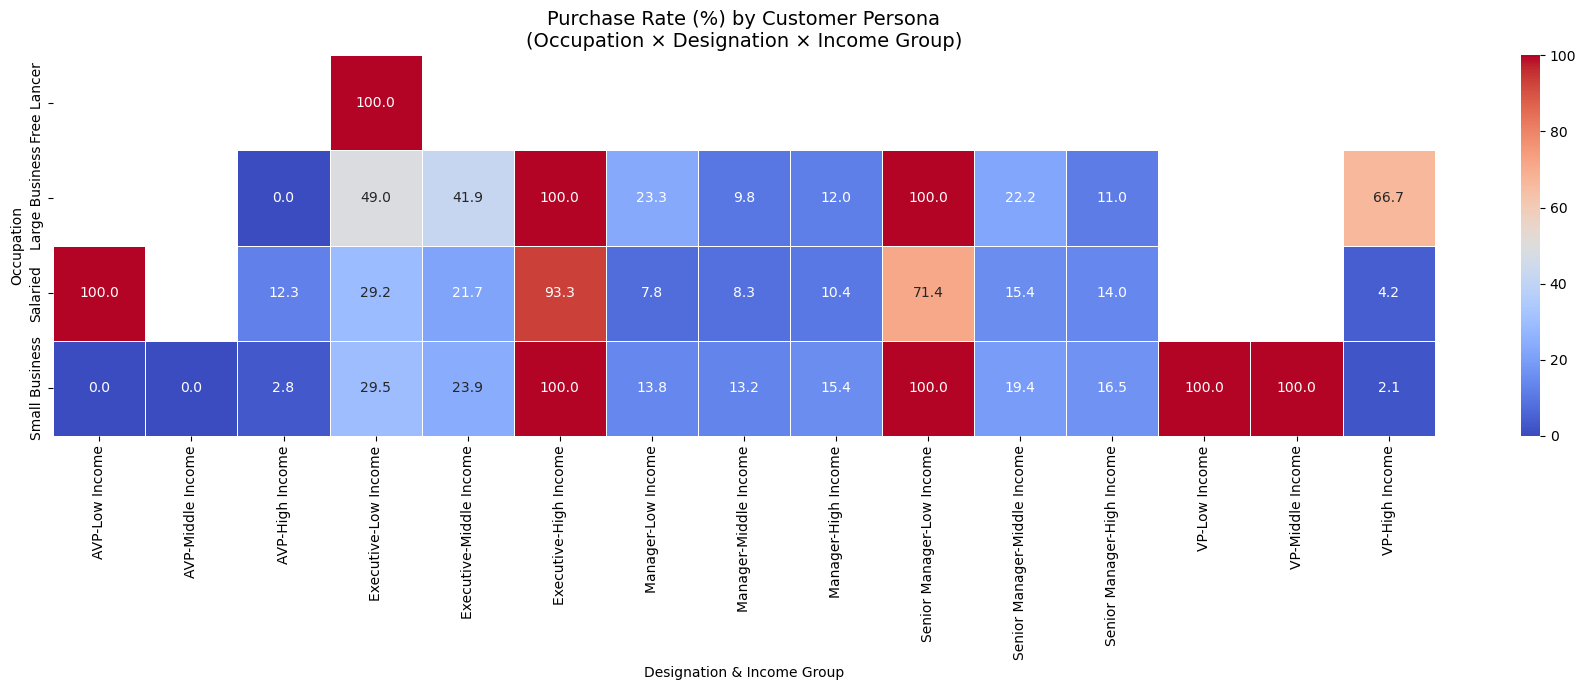

In [52]:

df['MonthlyIncome'] = pd.to_numeric(df['MonthlyIncome'], errors='coerce')
df['ProdTaken'] = pd.to_numeric(df['ProdTaken'], errors='coerce')


# Create Income Groups

df['IncomeGroup'] = pd.qcut(
    df['MonthlyIncome'],
    q=3,
    labels=['Low Income', 'Middle Income', 'High Income']
)


# Create Persona Table

persona = (
    df.groupby(
        ['Occupation', 'Designation', 'IncomeGroup'],
        observed=False
    )['ProdTaken']
    .mean()
    .reset_index()
)

# Convert to percentage
persona['ProdTaken'] = persona['ProdTaken'].astype(float) * 100


# Pivot Table for Heatmap

heatmap_data = persona.pivot_table(
    values='ProdTaken',
    index='Occupation',
    columns=['Designation', 'IncomeGroup'],
    aggfunc='mean',
    observed=False
)

#  CRITICAL FIX (avoid dtype=object error)
heatmap_data = heatmap_data.astype(float)


# Plot Heatmap

plt.figure(figsize=(18, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Purchase Rate (%) by Customer Persona\n"
    "(Occupation × Designation × Income Group)",
    fontsize=14
)

plt.xlabel("Designation & Income Group")
plt.ylabel("Occupation")
plt.tight_layout()
plt.show()


**Observation :-**

> Executive-level customers across multiple income groups show the highest purchase likelihood, especially **Freelancers and Large Business Executives**, whereas **senior corporate designations (AVP, VP, Senior Manager)** consistently reflect low conversion rates irrespective of their income category.

**Business Insight :-**

> Purchase behavior is driven more by **career flexibility and decision-making freedom** rather than income. **Executives and business owners show higher inclination toward travel packages**, while senior corporate professionals are less responsive due to tight schedules and different travel preferences.

**Conclusion :-**

> **The most profitable persona to target is “Executive-level Freelancers and Business Professionals,” as they offer the highest conversion opportunity. Marketing efforts should prioritize these segments over senior corporate roles to maximize ROI and accelerate sales performance.**

---
---

### 🔟 **Can demographic + behavioral factors combined (Age, MaritalStatus, NumberOfPersonVisiting, NumberOfChildrenVisiting) predict purchase likelihood?**
**(Do family profiles influence buying decisions?)**


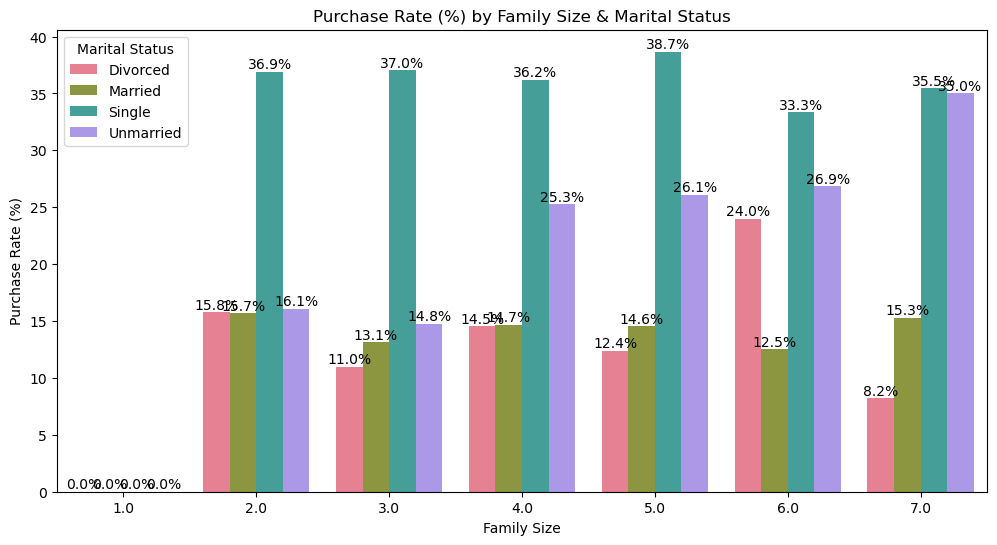

In [53]:
# Creating Family Size feature
df['FamilySize'] = df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']

# Purchase rate by Marital Status and Family Size
family = df.groupby(['MaritalStatus', 'FamilySize'])['ProdTaken'].mean().reset_index()
family['ProdTaken'] = family['ProdTaken'] * 100

plt.figure(figsize=(12,6))
ax = sns.barplot(x='FamilySize', y='ProdTaken', hue='MaritalStatus', data=family, palette='husl')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%') 

plt.title("Purchase Rate (%) by Family Size & Marital Status")
plt.xlabel("Family Size")
plt.ylabel("Purchase Rate (%)")
plt.legend(title="Marital Status")
plt.show()


**Observation :-**

> Customers with **larger family sizes (4–7 members)** show higher purchase rates compared to solo travelers. Among them, **Single and Unmarried customers demonstrate the strongest conversion**, while **Married customers remain moderate**, and **Divorced customers show the lowest purchase intent overall.**

**Business Insight :-**

> Travel decisions for family groups — especially among **Single and Unmarried individuals traveling with friends/relatives or siblings** — are highly influenced by group experiences and shared enjoyment. In contrast, **Married customers prioritize budgeting and planning**, reducing purchase likelihood; Divorced customers are the least responsive segment.

**Conclusion :-**

> **The ideal behavioral persona is a Single/Unmarried customer planning a trip with 4–7 people.** Targeting such customers with **group discounts, friends/family packages, and shared experience–focused marketing** can significantly increase conversion rates compared to traditional couple-focused or senior demographic promotions.


In [133]:
df= pd.read_csv(r"C:\Users\nikhi\Machine Learning\Project\Traveling_Data.csv")
df

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6,Salaried,Female,3,3,Deluxe,3,Single,1,1,2,1,0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14,Salaried,Male,3,4,Deluxe,4,Divorced,2,0,3,1,2,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8,Free Lancer,Male,3,4,Basic,3,Single,7,1,3,0,0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9,Salaried,Female,2,3,Basic,3,Divorced,2,1,5,1,1,Executive,17909.0
4,200005,0,32.0,Company Invited,1,8,Salaried,Male,3,3,Basic,3,Single,1,0,5,1,1,Executive,18068.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4123,204883,1,49.0,Self Enquiry,3,9,Small Business,Male,3,5,Deluxe,4,Unmarried,2,1,1,1,1,Manager,26576.0
4124,204884,1,28.0,Company Invited,1,31,Salaried,Male,4,5,Basic,3,Single,3,1,3,1,2,Executive,21212.0
4125,204885,1,52.0,Self Enquiry,3,17,Salaried,Female,4,4,Standard,4,Married,7,0,1,1,3,Senior Manager,31820.0
4126,204886,1,19.0,Self Enquiry,3,16,Small Business,Male,3,4,Basic,3,Single,3,0,5,0,2,Executive,20289.0
